# Joint clustering - two adult mouse brain sections from MERFISH

This notebook identifies shared spatial structures across spatial transcriptomics samples. spAlignDE computes BANKSY features separately within each sample, integrates the representations with joint PCA and Harmony, and applies Leiden clustering in the shared representation. Optional boundary-aware refinement is performed within each tissue section.

The raw Leiden labels and boundary-refined labels are retained as `adata.obs["cluster_raw"]` and `adata.obs["cluster_refined"]`. The selected final labels are written to `adata.obs["cluster"]`. The original expression matrix and `adata.obsm["spatial"]` coordinates are preserved.

**Fixed-seed reproducibility.** This workflow uses seed `1000`. Use the same input observations in the same order and the same workflow parameters, and set the seed before the first stochastic step. Two independent runs with these settings reproduced the reported output.

## Installation

From the repository root:

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[clustering,tutorial]"
```

Set the input path before executing the notebook. It may be either a combined `.h5ad` file:

```bash
export SPALIGNDE_INPUT=/path/to/data/merfishS2_joint.h5ad
```

or a directory containing paired CSV files:

```bash
export SPALIGNDE_INPUT=/path/to/data/csv_folder
```

## Example data

The example uses samples S2R2 and S2R3 from the Vizgen MERFISH Mouse Brain Receptor Map. These data provide a single-cell-resolution cross-sample benchmark. S2R3 is the query sample (85,958 cells) and S2R2 is the reference sample (84,172 cells), giving 170,130 cells and 649 measured genes in total.

spAlignDE accepts either a combined AnnData/`.h5ad` input or paired CSV files. Internally, both routes use one combined AnnData object with:

- `adata.X`: cell-by-gene counts or expression;
- `adata.obs["sample_id"]`: sample identity;
- `adata.obsm["spatial"]`: original x/y coordinates;
- globally unique `adata.obs_names`.

For CSV input, place one metadata/expression pair per sample in the same directory:

```text
cell_metadata_<sample_id>.csv   # cell_id, x, y, ...
cell_by_gene_<sample_id>.csv    # cell_id, gene_1, gene_2, ...
```

The loader matches rows by `cell_id`, aligns genes by column name, fills sample-specific missing genes with zero, and converts the result to the same AnnData layout.

In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import spAlignDE

WORKFLOW_SEED = 1000
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the spAlignDE repository")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_sample" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

data_value = os.environ.get("SPALIGNDE_INPUT") or os.environ.get("SPALIGNDE_MERFISH_H5AD")
if not data_value:
    raise EnvironmentError(
        "Set SPALIGNDE_INPUT to a combined .h5ad file or paired-CSV directory"
    )
INPUT_PATH = Path(data_value).expanduser().resolve()
print("Input:", INPUT_PATH.name)

Input: merfishS2_joint.h5ad


In [2]:
adata = spAlignDE.load_cross_sample_data(INPUT_PATH)
spAlignDE.validate_cross_sample_anndata(adata, require_cluster=False)

print(adata)
print("Sample sizes:")
print(adata.obs["sample_id"].value_counts().sort_index())
print("Genes:", adata.n_vars)
print("Original spatial shape:", adata.obsm["spatial"].shape)

AnnData object with n_obs × n_vars = 170130 × 649
    obs: 'x', 'y', 'sample_id', 'orig_cell_id', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'max_x', 'min_y', 'max_y', 'cell_id'
    obsm: 'spatial'
Sample sizes:
sample_id
S2R2    84172
S2R3    85958
Name: count, dtype: int64
Genes: 649
Original spatial shape: (170130, 2)


## Run joint BANKSY/Harmony/Leiden clustering

The defaults below match the primary cross-sample analysis: 30 spatial neighbors, BANKSY mixing parameter 0.8, 20 principal components, 50 neighbors in the shared-nearest-neighbor graph, and Leiden resolution 1.4.

In [3]:
config = spAlignDE.JointClusteringConfig(
    num_neighbors=30,
    banksy_lambda=0.8,
    pca_dim=20,
    resolution=1.4,
    snn_neighbors=50,
    harmony_theta=2.0,
    refine_boundaries=True,
    compute_umap=False,
    random_state=WORKFLOW_SEED,
    leiden_flavor="leidenalg",
    leiden_n_iterations=-1,
)

adata_clustered, clustering_details = spAlignDE.cluster_joint(
    adata,
    config=config,
    return_details=True,
)
spAlignDE.validate_cross_sample_anndata(adata_clustered)

print("Number of shared-label identities:", adata_clustered.obs["cluster"].nunique())
print(adata_clustered.obs.groupby(["sample_id", "cluster"], observed=False).size().unstack(fill_value=0))


Median distance to closest cell = 13.097533084495359

---- Ran median_dist_to_nearest_neighbour in 0.14 s ----



---- Ran generate_spatial_distance_graph in 0.61 s ----



---- Ran row_normalize in 0.15 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 1.54 s ----



---- Ran generate_spatial_distance_graph in 1.15 s ----



---- Ran theta_from_spatial_graph in 0.38 s ----



...


AGF matrix | Mean: 0.19 | Std: 0.78
Size of AGF mat (m = 1) | Shape: (85958, 649)
Top entries of AGF:
[[0.         0.70600393 1.60416172]
 [0.         0.22427414 1.61373663]
 [0.         0.28352317 1.51659332]]
Ran 'Create BANKSY Matrix' in 0.87 mins


Scale factors squared: [0.2        0.53333333 0.26666667]
Scale factors: [0.4472136  0.73029674 0.51639778]


2026-09-04 16:19:11,842 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2026-09-04 16:19:13,033 - harmonypy - INFO - KMeans initialization complete.


Number of shared-label identities: 28
cluster       0     1    10    11    12    13    14    15    16    18  ...  \
sample_id                                                              ...   
S2R2       7880  7242  4069  3371  2739  2178  2726  2035  1834  1719  ...   
S2R3       7840  8434  4426  4258  2412  2305  2230  2178  2150  1606  ...   

cluster     26   27   28     3     4     5     6     7     8     9  
sample_id                                                           
S2R2       246  427  211  6905  5399  4744  3946  3778  4464  4020  
S2R3       314    0    0  6961  5474  5385  4458  3505  4845  3950  

[2 rows x 28 columns]


### How to adapt the clustering parameters

Tune clustering before changing alignment parameters. Keep the random seed and
all other settings fixed while comparing a small grid of candidate values.

- `num_neighbors`: increasing it summarizes a broader spatial neighborhood and
  usually smooths structures; reduce it if thin domains disappear.
- `banksy_lambda`: increasing it gives spatial-neighborhood information more
  influence relative to each observation's own expression.
- `resolution`: increasing it usually produces more Leiden clusters. Reject
  settings that create many tiny sample-specific fragments or merge clearly
  distinct spatial domains.
- `snn_neighbors` and `harmony_theta` (joint clustering only): the former
  broadens graph connectivity and the latter strengthens sample correction.
  Do not erase biological differences merely to maximize shared labels.
- `refine_boundaries`: compare `cluster_raw` and `cluster_refined` spatially.
  Refinement should remove isolated boundary noise without erasing narrow
  structures.

Select a configuration using spatial coherence, boundary preservation, cluster
size and coverage in every required sample. Cluster integer values are
arbitrary and may be renumbered across runs; compare memberships and maps, not
label numbers. The website **Parameter Tuning Guide** gives the complete
clustering-to-alignment tuning order.

## Inspect raw and refined spatial structures

The top row shows the raw clusters obtained from joint Leiden clustering; the bottom row shows the result after boundary-aware refinement within each tissue section. Columns correspond to the two datasets. All four panels use one shared label-to-color mapping, so a cluster identity has the same color before and after refinement and across samples.

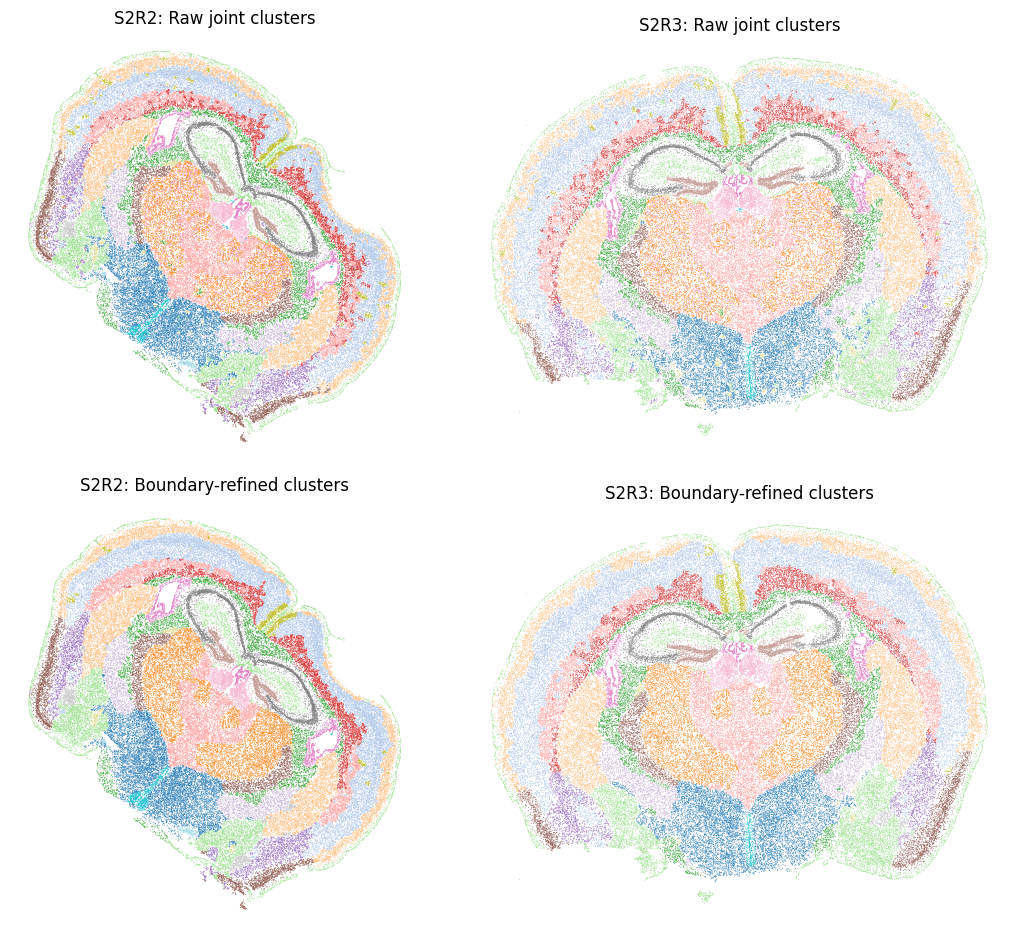

,n_cells,n_changed,pct_changed,n_boundary,n_boundary_changed,n_protected_changed
S2R2,84172.0,9038.0,0.107375,3618.0,12.0,5.0
S2R3,85958.0,9634.0,0.112078,2846.0,7.0,1.0


In [4]:
fig, axes = spAlignDE.plot_joint_cluster_refinement(
    adata_clustered,
    samples=["S2R2", "S2R3"],
    point_size=0.5,
    palette="tab20",
)
plt.show()

clustering_details["refinement_stats"]

## Save the clustered AnnData

The saved file is the input to the alignment notebook. It retains the original expression matrix and coordinates and adds `adata.obs["cluster_raw"]`, `adata.obs["cluster_refined"]`, and the final alignment label `adata.obs["cluster"]`.

In [5]:
clustered_path = OUTPUT_DIR / "merfish_S2_joint_clustered.h5ad"
adata_clustered.write_h5ad(clustered_path)

print("Saved:", clustered_path.relative_to(PROJECT_ROOT))
print("Output shape:", adata_clustered.shape)
print("Cluster columns:", ["cluster_raw", "cluster_refined", "cluster"])
print("Required alignment columns:", ["sample_id", "cluster"])
print("Spatial key: adata.obsm['spatial']")

Saved: tutorials/cross_sample/output/merfish_S2_joint_clustered.h5ad
Output shape: (170130, 649)
Cluster columns: ['cluster_raw', 'cluster_refined', 'cluster']
Required alignment columns: ['sample_id', 'cluster']
Spatial key: adata.obsm['spatial']
